# pulling temperature data 

Primero descargamos el dataset de socrata

Link: https://dev.socrata.com/foundry/www.datos.gov.co/sbwg-7ju4 

Pesa 15GB

In [9]:
import os
import sys
import findspark
import warnings

warnings.filterwarnings("ignore")

# Actualizamos a la ruta de Java 17
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

# Aseguramos que use el Python del entorno de uv
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
try:
    import pyspark
    findspark.init() # findspark buscará automáticamente en .venv
    from pyspark.sql import SparkSession
    
    spark = SparkSession.builder \
        .appName("PruebaSpark") \
        .config("spark.driver.memory", "2g") \
        .getOrCreate()
    
    print("¡Sesión de Spark creada con éxito en Python 3.12!")
    spark.stop()
except Exception as e:
    print(f"Error al iniciar Spark: {e}")

26/05/12 20:33:21 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


¡Sesión de Spark creada con éxito en Python 3.12!


In [14]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, DoubleType

from pyspark.sql.types import StructType, StructField, StringType, DoubleType

# Esquema basado exactamente en los nombres que proporcionaste
schema_soda = StructType([
    StructField("CodigoEstacion", StringType(), True),
    StructField("CodigoSensor", StringType(), True),
    StructField("FechaObservacion", StringType(), True),
    StructField("ValorObservado", DoubleType(), True),
    StructField("NombreEstacion", StringType(), True),
    StructField("Departamento", StringType(), True),
    StructField("Municipio", StringType(), True),
    StructField("ZonaHidrografica", StringType(), True),
    StructField("Latitud", DoubleType(), True),
    StructField("Longitud", DoubleType(), True),
    StructField("DescripcionSensor", StringType(), True),
    StructField("UnidadMedida", StringType(), True)
])

# Lectura del CSV con el esquema correcto
csv_path = "/home/pxtroniwnl/Downloads/temperature-soda.csv"

df = spark.read.format("csv") \
    .option("header", "true") \
    .option("sep", ",") \
    .schema(schema_soda) \
    .load(csv_path)

# Verificación de que los datos están en su sitio
print("Verificando alineación de columnas:")
df.show(5)

Verificando alineación de columnas:
+--------------+------------+--------------------+--------------+----------------+---------------+-----------+----------------+-----------+------------+-----------------+------------+
|CodigoEstacion|CodigoSensor|    FechaObservacion|ValorObservado|  NombreEstacion|   Departamento|  Municipio|ZonaHidrografica|    Latitud|    Longitud|DescripcionSensor|UnidadMedida|
+--------------+------------+--------------------+--------------+----------------+---------------+-----------+----------------+-----------+------------+-----------------+------------+
|    0023125501|        0068|2017 Aug 21 05:30...|      23.89136|    PAUNA  - AUT|         BOYACÁ|      PAUNA| MEDIO MAGDALENA|5.657130556|-73.96032778|    Temp Aire 2 m|          °C|
|    0029065000|        0068|2019 Jun 19 06:00...|          30.5|MEDIA LUNA - AUT|      MAGDALENA|    PIVIJAI|  BAJO MAGDALENA|10.51002778|-74.50666667|    Temp Aire 2 m|          °C|
|    0021202180|        0068|2011 Aug 01 01:

In [15]:
# Filtrar por municipio y ver qué estaciones tenemos disponibles
df_local = df.filter(df.Municipio == "CARTAGENA")

# Ver estaciones únicas y su ubicación para seleccionar la mejor
df_local.select("NombreEstacion", "Latitud", "Longitud").distinct().show(truncate=False)

+--------------------------+-------+--------+
|NombreEstacion            |Latitud|Longitud|
+--------------------------+-------+--------+
|APTO RAFAEL NUÑEZ  TX GPRS|10.447 |-75.516 |
+--------------------------+-------+--------+



Ya sabiendo la estacion mas cerca a la laguna lo que procedemos a hacer es filtramos todos los datos que no sirven para nuestra laguna de barcelona de indias

In [18]:
from pyspark.sql import functions as F

# 1. Configuración de sesión y limpieza de fecha
# (Asumiendo que df ya existe con el esquema de 12 columnas)
df_barcelona = df.filter(
    (df.NombreEstacion.contains("RAFAEL NUÑEZ")) & 
    (df.Municipio == "CARTAGENA")
)

df_final = df_barcelona.withColumn(
    "Fecha", 
    F.to_timestamp("FechaObservacion", "yyyy MMM dd hh:mm:ss a")
).filter(F.col("Fecha").isNotNull())

# 2. Exportación a CSV
# Usamos coalesce(1) para que sea un solo archivo
path_temp = "/home/pxtroniwnl/Downloads/temp_folder"

df_final.coalesce(1).write.mode("overwrite") \
    .option("header", "true") \
    .option("sep", ",") \
    .csv(path_temp)

# 3. Truco de terminal para renombrar el archivo a 'datos_temp_barcelona.csv'
import glob

# Buscamos el archivo .csv que generó Spark dentro de la carpeta
generated_file = glob.glob(f"{path_temp}/*.csv")[0]
final_name = "/home/pxtroniwnl/Downloads/datos_temp_barcelona.csv"

os.rename(generated_file, final_name)
print(f"Archivo exportado exitosamente como: {final_name}")

Archivo exportado exitosamente como: /home/pxtroniwnl/Downloads/datos_temp_barcelona.csv


---

In [37]:
import pandas as pd

# 1. Cargar el archivo
# Ajustamos la ruta al nombre exacto que pediste
path = "data/extra/datos_temp_barcelona.csv"

df_pandas = pd.read_csv(path)

# 2. Convertir la columna Fecha a objeto datetime
# Spark ya la exportó en formato estándar, así que Pandas la reconocerá fácil
df_pandas['Fecha'] = pd.to_datetime(df_pandas['Fecha'])

# 3. Establecer la Fecha como índice (Crucial para Series de Tiempo)
df_pandas = df_pandas.set_index('Fecha').sort_index()

In [38]:
df_pandas.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 41500 entries, 2014-09-02 17:00:00-05:00 to 2019-09-14 23:00:00-05:00
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CodigoEstacion     41500 non-null  int64  
 1   CodigoSensor       41500 non-null  int64  
 2   FechaObservacion   41500 non-null  str    
 3   ValorObservado     41500 non-null  float64
 4   NombreEstacion     41500 non-null  str    
 5   Departamento       41500 non-null  str    
 6   Municipio          41500 non-null  str    
 7   ZonaHidrografica   41500 non-null  str    
 8   Latitud            41500 non-null  float64
 9   Longitud           41500 non-null  float64
 10  DescripcionSensor  41500 non-null  str    
 11  UnidadMedida       41500 non-null  str    
dtypes: float64(3), int64(2), str(7)
memory usage: 8.1 MB


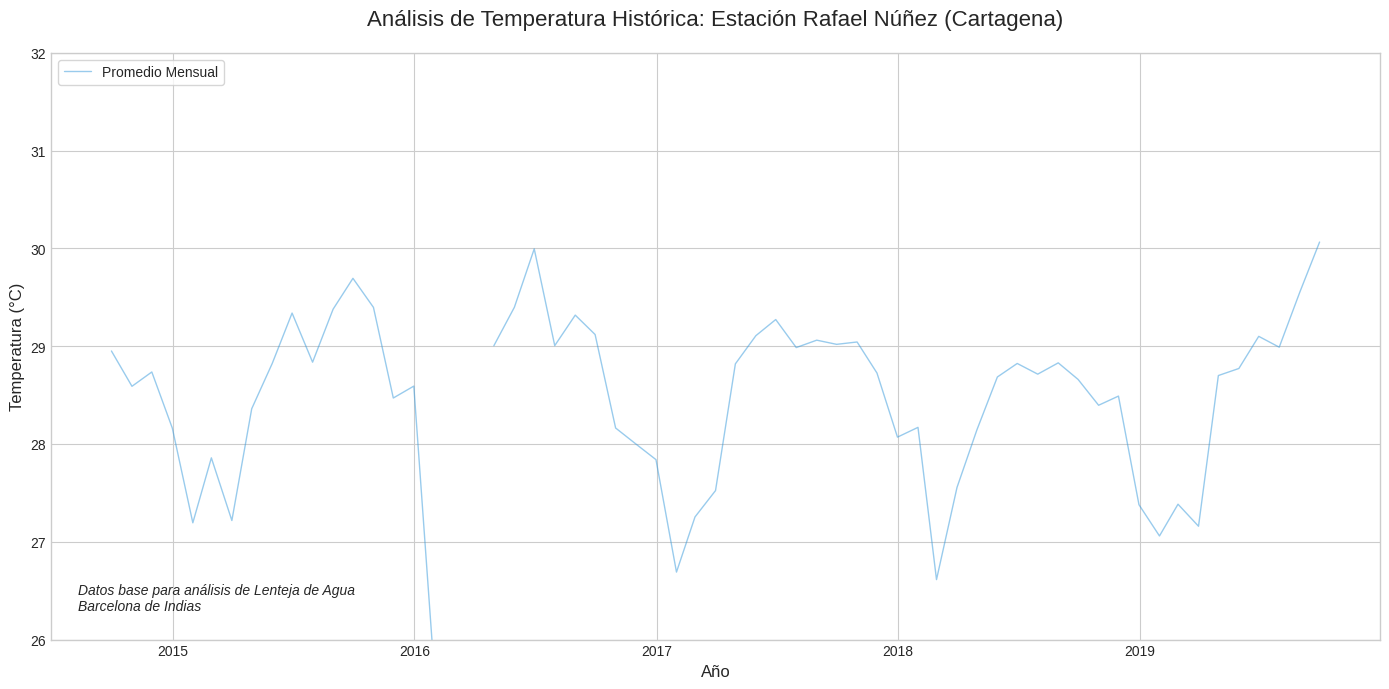

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo para que se vea académico (IEEE style)
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(14, 7))

# 1. Remuestreo para ver la tendencia (Promedio Mensual)
# Usamos 'ME' por la actualización de Pandas que vimos anteriormente
df_mensual = df_pandas['ValorObservado'].resample('ME').mean()

# 2. Graficar
ax.plot(df_mensual, label='Promedio Mensual', color='#3498db', alpha=0.5, linewidth=1)

# 3. Personalización técnica
ax.set_title('Análisis de Temperatura Histórica: Estación Rafael Núñez (Cartagena)', fontsize=16, pad=20)
ax.set_ylabel('Temperatura (°C)', fontsize=12)
ax.set_xlabel('Año', fontsize=12)
ax.set_ylim(26, 32)  # Enfocamos el rango de variación térmica de Cartagena

ax.legend(frameon=True, loc='upper left')
ax.annotate('Datos base para análisis de Lenteja de Agua\nBarcelona de Indias', 
            xy=(0.02, 0.05), xycoords='axes fraction', fontsize=10, fontstyle='italic')

plt.tight_layout()
plt.show()

Vemos en ese bajonazo que realmente hubo un fuerte problema de continuidad de datos en el 2016 por lo que de aqui no nos podemos guiar del todo al menos en ese punto donde no hay datos aunque podriamos intentar simputar esos datos, existen 3 formas...

1. Imputacion por estacionalidad mensual: La forma más física de llenar un hueco en meteorología es usar el promedio histórico de ese mismo mes. Si falta un dato en "Octubre 2016", lo llenamos con el promedio de todos los "Octubres" de otros años. Esto respeta los ciclos de lluvia y sequía de la costa Caribe. 

2. Imputación por Vecindad Temporal (Spline Interpolation): La temperatura no cambia de forma lineal (puntas afiladas); se mueve en curvas suaves debido a la inercia térmica del aire y el océano. Una interpolación tipo spline es más realista físicamente que una lineal.

3. Modelo de Descomposición (STL): Esta es la técnica más robusta. Separamos la serie en Tendencia + Estacionalidad + Residuo. Imputamos sobre la estacionalidad y la tendencia, y luego recomponemos.

Usaremos el 3 porque es mas robusto

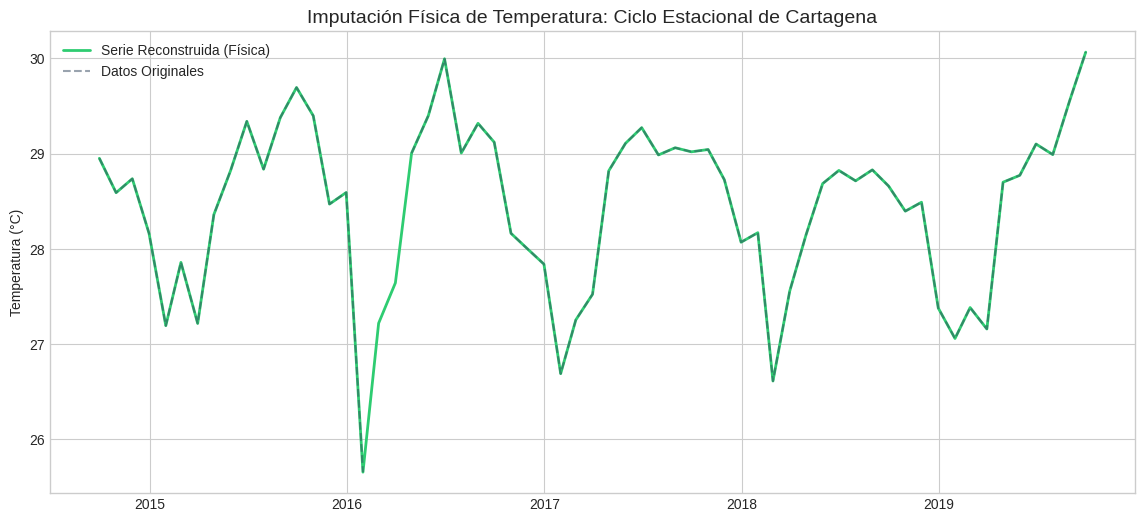

In [40]:
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np

# 1. Limpieza Física: Eliminar outliers (errores de sensor)
# En Cartagena, un promedio mensual < 24°C es físicamente imposible
df_clean = df_pandas['ValorObservado'].resample('ME').mean()
df_clean[df_clean < 24] = np.nan

# 2. Descomposición Estacional para capturar el "ADN" del clima
# Usamos interpolación temporal rápida solo para poder descomponer
temp_interpolated = df_clean.interpolate(method='time')
result = seasonal_decompose(temp_interpolated, model='additive', period=12)

# 3. CREAR EL "DATO FÍSICO": Tendencia + Estacionalidad
# Esto ignora el 'residuo' (el ruido/error) y nos da el valor climático puro
df_fisico = result.trend + result.seasonal

# 4. Imputación Final: 
# Si hay dato real, lo dejamos. Si es NaN o error, usamos el valor físico.
df_final = df_clean.fillna(df_fisico)

# 5. Visualización de Calidad Académica
plt.figure(figsize=(14, 6))
plt.plot(df_final, label='Serie Reconstruida (Física)', color='#2ecc71', linewidth=2)
plt.plot(df_clean, label='Datos Originales', color='#34495e', alpha=0.5, linestyle='--')
plt.title('Imputación Física de Temperatura: Ciclo Estacional de Cartagena', fontsize=14)
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.show()

In [41]:
# 1. Definir la ruta de destino
output_path = "data/extra"

# 2. Preparar el DataFrame para exportación
# Convertimos la serie df_final a un DataFrame y le damos un nombre claro a la columna
df_export = df_final.to_frame(name='Temperatura_Reconstruida')

# Añadimos una columna booleana para identificar qué datos fueron imputados
df_export['Es_Imputado'] = df_clean.isna()

# 3. Exportar a CSV
final_file_path = os.path.join(output_path, "datos_temp_reconstruida_barcelona.csv")
df_export.to_csv(final_file_path, index=True, index_label='Fecha')

print(f"Exportación completada exitosamente en: {final_file_path}")

Exportación completada exitosamente en: data/extra/datos_temp_reconstruida_barcelona.csv
